In [87]:
#!pip install --upgrade matplotlib
#!conda install -y basemap
# !pip install bs4 --user

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sea
import requests
import os
import conda
import re 
import time

conda_file_dir = conda.__file__
conda_dir = conda_file_dir.split('lib')[0]
proj_lib = os.path.join(os.path.join(conda_dir, 'share'), 'proj')
os.environ["PROJ_LIB"] = proj_lib

from mpl_toolkits.basemap import Basemap
from bs4 import BeautifulSoup

import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

In [21]:
source = pd.read_csv('rankings_1973-2017_csv.csv')

In [44]:
df=source[source["week_month"]==1]
df=df[df['week_day']<8]
df.head(100)

,week_title,week_year,week_month,week_day,rank_text,rank_number,move_positions,move_direction,player_age,ranking_points,tourneys_played,player_url,player_slug,player_id
85646,2017.01.02,2017,1,2,1,1,NaN,NaN,29.0,12410,16,/en/players/andy-murray/mc10/overview,andy-murray,mc10
85647,2017.01.02,2017,1,2,2,2,NaN,NaN,29.0,11780,17,/en/players/novak-djokovic/d643/overview,novak-djokovic,d643
85648,2017.01.02,2017,1,2,3,3,NaN,NaN,26.0,5450,19,/en/players/milos-raonic/r975/overview,milos-raonic,r975
85649,2017.01.02,2017,1,2,4,4,NaN,NaN,31.0,5315,21,/en/players/stan-wawrinka/w367/overview,stan-wawrinka,w367
85650,2017.01.02,2017,1,2,5,5,NaN,NaN,27.0,4905,20,/en/players/kei-nishikori/n552/overview,kei-nishikori,n552
85651,2017.01.02,2017,1,2,6,6,NaN,NaN,28.0,3650,22,/en/players/marin-cilic/c977/overview,marin-cilic,c977
85652,2017.01.02,2017,1,2,7,7,NaN,NaN,30.0,3625,18,/en/players/gael-monfils/mc65/overview,gael-monfils,mc65
85653,2017.01.02,2017,1,2,8,8,NaN,NaN,23.0,3415,28,/en/players/dominic-thiem/tb69/overview,dominic-thiem,tb69
85654,2017.01.02,2017,1,2,9,9,NaN,NaN,30.0,3300,16,/en/players/rafael-nadal/n409/overview,rafael-nadal,n409
85655,2017.01.02,2017,1,2,10,10,NaN,NaN,31.0,3060,21,/en/players/tomas-berdych/ba47/overview,tomas-berdych,ba47


In [45]:
df.count()

week_title         51991
week_year          51991
week_month         51991
week_day           51991
rank_text          51991
rank_number        51991
move_positions     21969
move_direction     21969
player_age         47392
ranking_points     51991
tourneys_played    51991
player_url         51991
player_slug        51991
player_id          51991
dtype: int64

In [46]:
df=df[df['rank_number']<=250]
df.count()

week_title         8037
week_year          8037
week_month         8037
week_day           8037
rank_text          8037
rank_number        8037
move_positions     2886
move_direction     2886
player_age         8029
ranking_points     8037
tourneys_played    8037
player_url         8037
player_slug        8037
player_id          8037
dtype: int64

In [47]:
df=df[['player_slug','player_url']].drop_duplicates()
df.count()

player_slug    1688
player_url     1688
dtype: int64

In [48]:
df.head()

,player_slug,player_url
85646,andy-murray,/en/players/andy-murray/mc10/overview
85647,novak-djokovic,/en/players/novak-djokovic/d643/overview
85648,milos-raonic,/en/players/milos-raonic/r975/overview
85649,stan-wawrinka,/en/players/stan-wawrinka/w367/overview
85650,kei-nishikori,/en/players/kei-nishikori/n552/overview


In [82]:
def getplayerheadshot(player_url):
    try:
        url = 'https://www.atptour.com' + player_url
        pattern = "src='/-/media/tennis/players/head-shot/.*'"
        response = (requests.get(url).text)
        #print(response)
        matches = re.findall(pattern,response,re.MULTILINE)
        time.sleep(0.5)
        print('https://www.atptour.com'+matches[0][5:-1])
        if len(matches)!=0:
            return 'https://www.atptour.com' + matches[0][5:-1]
        else:
            return "http://nycretailleasing.com/wp-content/uploads/2018/07/PF-Headshot-Placeholder.jpg"
        return response_json
    
    except Exception as e:
        raise e
        
#df["img_url"]=df["player_url"].apply(getplayerheadshot)
temp = df["player_url"].head(1).apply(getplayerheadshot)

https://www.atptour.com/-/media/tennis/players/head-shot/2019/bautista-agut_head_ao19.png


In [107]:

def getplayerheadshot2(player_url):
    try:
        url = 'https://www.atptour.com' + player_url
        pattern = "src='/-/media/tennis/players/head-shot/.*'"
        response = (requests.get(url).text)
        #print(response)
        soup = BeautifulSoup(response, 'html5lib')
        divs = soup.findAll("div",{"class":"last-events-played-image"})
        for div in divs:
            a = div.find("a",{"href":player_url})
            if a :
                return 'https://www.atptour.com'+ a.find("img")['src']
        
        return 'https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png'
    
    except Exception as e:
        raise e

    

df["img_url"]=df["player_url"].apply(getplayerheadshot2)

In [105]:
print(temp.values)

[ 'https://www.atptour.com/-/media/tennis/players/head-shot/compressed/borg-headshot-getty.png'
 'https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png']


In [110]:
df.tail().values

array([['helmut-beermann', '/en/players/helmut-beermann/b031/overview',
        'https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png'],
       ['colin-dibley', '/en/players/colin-dibley/d076/overview',
        'https://www.atptour.com/-/media/tennis/players/head-shot/lq/retired/dibley_c_headshot_lq.png'],
       ['jan-norback', '/en/players/jan-norback/n047/overview',
        'https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png'],
       ['bjorn-borg', '/en/players/bjorn-borg/b058/overview',
        'https://www.atptour.com/-/media/tennis/players/head-shot/compressed/borg-headshot-getty.png'],
       ['sammy-giammalva%20sr.',
        '/en/players/sammy-giammalva%20sr./g178/overview',
        'https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png']], dtype=object)

In [166]:
df_img = df

In [167]:
from PIL import Image
from io import BytesIO
from IPython.display import display
def getplayerimage(player_url):
    try:
        response = requests.get(player_url,stream=True)
        return response.content
    
    except Exception as e:
        raise e
df_img["player_image"] = df_img["img_url"].apply(getplayerimage)

In [171]:
df_img.head()

,player_slug,player_url,img_url,player_image
85646,andy-murray,/en/players/andy-murray/mc10/overview,https://www.atptour.com/-/media/tennis/players...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
85647,novak-djokovic,/en/players/novak-djokovic/d643/overview,https://www.atptour.com/-/media/tennis/players...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
85648,milos-raonic,/en/players/milos-raonic/r975/overview,https://www.atptour.com/-/media/tennis/players...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
85649,stan-wawrinka,/en/players/stan-wawrinka/w367/overview,https://www.atptour.com/-/media/tennis/players...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...
85650,kei-nishikori,/en/players/kei-nishikori/n552/overview,https://www.atptour.com/-/media/tennis/players...,b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\...


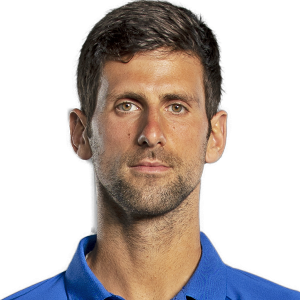

In [191]:
display(Image.open(BytesIO(df_img["player_image"].reset_index(drop=True)[1])))

In [202]:
#!pip install --upgrade matplotlib
import mysql.connector as sql
db_connection = sql.connect(host='your-host', database='your-database', user='your-username', password='your-password')
wta = pd.read_sql('SELECT ID,CONCAT(First," ",Last) AS Name FROM Player p JOIN (SELECT distinct PlayerID, Gender FROM Ranking WHERE Gender="Female" AND Position <=150) r ON p.ID=r.PlayerID AND p.Gender=r.Gender',db_connection)
wta


,ID,Name
0,'201401',Abigail Spears
1,'200088',Adriana Gersi
2,'207450',Adriana Sandoval
3,'200727',Adriana Serra Zanetti
4,'200447',Adriana Villagran Reami
5,'201497',Agnes Szavay
6,'201474',Agnieszka Radwanska
7,'201475',Ahsha Rolle
8,'200085',Ai Sugiyama
9,'201411',Aiko Nakamura


In [218]:
def geturlstring(row):
    if row is not None:
        return "_".join(row.split(" "))
    else:
        return ""
wta["url"]=wta["Name"].apply(geturlstring)
wta

,ID,Name,url
0,'201401',Abigail Spears,Abigail_Spears
1,'200088',Adriana Gersi,Adriana_Gersi
2,'207450',Adriana Sandoval,Adriana_Sandoval
3,'200727',Adriana Serra Zanetti,Adriana_Serra_Zanetti
4,'200447',Adriana Villagran Reami,Adriana_Villagran_Reami
5,'201497',Agnes Szavay,Agnes_Szavay
6,'201474',Agnieszka Radwanska,Agnieszka_Radwanska
7,'201475',Ahsha Rolle,Ahsha_Rolle
8,'200085',Ai Sugiyama,Ai_Sugiyama
9,'201411',Aiko Nakamura,Aiko_Nakamura


In [259]:
wta

,ID,Name,url
0,'201401',Abigail Spears,Abigail_Spears
1,'200088',Adriana Gersi,Adriana_Gersi
2,'207450',Adriana Sandoval,Adriana_Sandoval
3,'200727',Adriana Serra Zanetti,Adriana_Serra_Zanetti
4,'200447',Adriana Villagran Reami,Adriana_Villagran_Reami
5,'201497',Agnes Szavay,Agnes_Szavay
6,'201474',Agnieszka Radwanska,Agnieszka_Radwanska
7,'201475',Ahsha Rolle,Ahsha_Rolle
8,'200085',Ai Sugiyama,Ai_Sugiyama
9,'201411',Aiko Nakamura,Aiko_Nakamura


In [266]:
#!pip install --upgrade lxml
from bs4 import BeautifulSoup
def getplayerheadshot3(player_url):
    try:
        url = 'https://en.wikipedia.org/wiki/' + player_url
        response = requests.get(url)
        if(response.status_code!=200 and response.status_code!=304):
            return "https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg"
        
        body = response.content
        soup = BeautifulSoup(body)
        vboxcard = soup.find("table",{"class","infobox vcard"})
        if(vboxcard is None):
            return "https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg"
        else:
            soup = BeautifulSoup(str(vboxcard))
            links = soup.find("a",{"class","image"})
            if(links is None):
                    return "https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg"
                
            image = BeautifulSoup(str(links)).find("img")
            print(image)
            if(image is None):
                print("https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg")
                return "https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg"
            else:
                print("http:"+str(image["src"]))
                return "http:"+str(image["src"])
    
    except Exception as e:
        raise e

wta["img_url"] = wta["url"].apply(getplayerheadshot3)

<img alt="Spears 2009 US Open 01.jpg" data-file-height="2134" data-file-width="1707" decoding="async" height="275" src="//upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Spears_2009_US_Open_01.jpg/220px-Spears_2009_US_Open_01.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Spears_2009_US_Open_01.jpg/330px-Spears_2009_US_Open_01.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Spears_2009_US_Open_01.jpg/440px-Spears_2009_US_Open_01.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/5/5b/Spears_2009_US_Open_01.jpg/220px-Spears_2009_US_Open_01.jpg
<img alt="Agnes Szavay.jpg" data-file-height="2759" data-file-width="2785" decoding="async" height="218" src="//upload.wikimedia.org/wikipedia/commons/thumb/3/36/Agnes_Szavay.jpg/220px-Agnes_Szavay.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/3/36/Agnes_Szavay.jpg/330px-Agnes_Szavay.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/3/36/Agnes_Szavay.jpg/440px-Agnes_Szav

<img alt="Aleksandra Wozniak 2012 Budapest.JPG" data-file-height="2988" data-file-width="2000" decoding="async" height="329" src="//upload.wikimedia.org/wikipedia/commons/thumb/5/50/Aleksandra_Wozniak_2012_Budapest.JPG/220px-Aleksandra_Wozniak_2012_Budapest.JPG" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/5/50/Aleksandra_Wozniak_2012_Budapest.JPG/330px-Aleksandra_Wozniak_2012_Budapest.JPG 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/5/50/Aleksandra_Wozniak_2012_Budapest.JPG/440px-Aleksandra_Wozniak_2012_Budapest.JPG 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/5/50/Aleksandra_Wozniak_2012_Budapest.JPG/220px-Aleksandra_Wozniak_2012_Budapest.JPG
<img alt="Glatch WM13-009 (9461200354).jpg" data-file-height="3691" data-file-width="2538" decoding="async" height="320" src="//upload.wikimedia.org/wikipedia/commons/thumb/2/22/Glatch_WM13-009_%289461200354%29.jpg/220px-Glatch_WM13-009_%289461200354%29.jpg" srcset="//upload.wikimedia.org/wikipedia/comm

<img alt="Cornet US16 (15) (29569803900).jpg" data-file-height="3361" data-file-width="2254" decoding="async" height="328" src="//upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Cornet_US16_%2815%29_%2829569803900%29.jpg/220px-Cornet_US16_%2815%29_%2829569803900%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Cornet_US16_%2815%29_%2829569803900%29.jpg/330px-Cornet_US16_%2815%29_%2829569803900%29.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Cornet_US16_%2815%29_%2829569803900%29.jpg/440px-Cornet_US16_%2815%29_%2829569803900%29.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Cornet_US16_%2815%29_%2829569803900%29.jpg/220px-Cornet_US16_%2815%29_%2829569803900%29.jpg
<img alt="Lim WMQ14 (14606396182).jpg" data-file-height="3389" data-file-width="2461" decoding="async" height="303" src="//upload.wikimedia.org/wikipedia/commons/thumb/5/53/Lim_WMQ14_%2814606396182%29.jpg/220px-Lim_WMQ14_%2814606396182%29.jpg" srcset="//uplo

<img alt="Konjuh WM17 (23) (36183607035).jpg" data-file-height="3720" data-file-width="2480" decoding="async" height="330" src="//upload.wikimedia.org/wikipedia/commons/thumb/7/77/Konjuh_WM17_%2823%29_%2836183607035%29.jpg/220px-Konjuh_WM17_%2823%29_%2836183607035%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/7/77/Konjuh_WM17_%2823%29_%2836183607035%29.jpg/330px-Konjuh_WM17_%2823%29_%2836183607035%29.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/7/77/Konjuh_WM17_%2823%29_%2836183607035%29.jpg/440px-Konjuh_WM17_%2823%29_%2836183607035%29.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/7/77/Konjuh_WM17_%2823%29_%2836183607035%29.jpg/220px-Konjuh_WM17_%2823%29_%2836183607035%29.jpg
<img alt="Medina Garrigues RG15 (1) (19307244445).jpg" data-file-height="2992" data-file-width="1992" decoding="async" height="330" src="//upload.wikimedia.org/wikipedia/commons/thumb/6/64/Medina_Garrigues_RG15_%281%29_%2819307244445%29.jpg/220px-Medina_Garr

<img alt="Andrea Jaeger.jpg" data-file-height="293" data-file-width="200" decoding="async" height="293" src="//upload.wikimedia.org/wikipedia/commons/f/fa/Andrea_Jaeger.jpg" width="200"/>
http://upload.wikimedia.org/wikipedia/commons/f/fa/Andrea_Jaeger.jpg
<img alt="Andrea Petkovic (28136217445).jpg" data-file-height="3819" data-file-width="2709" decoding="async" height="310" src="//upload.wikimedia.org/wikipedia/commons/thumb/7/79/Andrea_Petkovic_%2828136217445%29.jpg/220px-Andrea_Petkovic_%2828136217445%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/7/79/Andrea_Petkovic_%2828136217445%29.jpg/330px-Andrea_Petkovic_%2828136217445%29.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/7/79/Andrea_Petkovic_%2828136217445%29.jpg/440px-Andrea_Petkovic_%2828136217445%29.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/7/79/Andrea_Petkovic_%2828136217445%29.jpg/220px-Andrea_Petkovic_%2828136217445%29.jpg
<img alt="Andrea Temesvari RG 2011.jpg" da

...

<img alt="Pereira WMQ13-007.jpg" data-file-height="3773" data-file-width="2469" decoding="async" height="336" src="//upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Pereira_WMQ13-007.jpg/220px-Pereira_WMQ13-007.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Pereira_WMQ13-007.jpg/330px-Pereira_WMQ13-007.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Pereira_WMQ13-007.jpg/440px-Pereira_WMQ13-007.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/0/0f/Pereira_WMQ13-007.jpg/220px-Pereira_WMQ13-007.jpg
<img alt="Martincova WMQ18 (9) (42647207685).jpg" data-file-height="3173" data-file-width="2119" decoding="async" height="329" src="//upload.wikimedia.org/wikipedia/commons/thumb/9/90/Martincova_WMQ18_%289%29_%2842647207685%29.jpg/220px-Martincova_WMQ18_%289%29_%2842647207685%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/9/90/Martincova_WMQ18_%289%29_%2842647207685%29.jpg/330px-Martincova_WMQ18_%289%29_%2842647207685%2

<img alt="ValerieTetreault.jpg" data-file-height="1100" data-file-width="1330" decoding="async" height="182" src="//upload.wikimedia.org/wikipedia/commons/thumb/9/97/ValerieTetreault.jpg/220px-ValerieTetreault.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/9/97/ValerieTetreault.jpg/330px-ValerieTetreault.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/9/97/ValerieTetreault.jpg/440px-ValerieTetreault.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/9/97/ValerieTetreault.jpg/220px-ValerieTetreault.jpg
<img alt="King V. US16 (4) (29780153461).jpg" data-file-height="3034" data-file-width="2019" decoding="async" height="331" src="//upload.wikimedia.org/wikipedia/commons/thumb/4/4b/King_V._US16_%284%29_%2829780153461%29.jpg/220px-King_V._US16_%284%29_%2829780153461%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/4/4b/King_V._US16_%284%29_%2829780153461%29.jpg/330px-King_V._US16_%284%29_%2829780153461%29.jpg 1.5x, //upload.wikimedi

<img alt="Duval WM16 (28340186281).jpg" data-file-height="2612" data-file-width="1742" decoding="async" height="330" src="//upload.wikimedia.org/wikipedia/commons/thumb/4/48/Duval_WM16_%2828340186281%29.jpg/220px-Duval_WM16_%2828340186281%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/4/48/Duval_WM16_%2828340186281%29.jpg/330px-Duval_WM16_%2828340186281%29.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/4/48/Duval_WM16_%2828340186281%29.jpg/440px-Duval_WM16_%2828340186281%29.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/4/48/Duval_WM16_%2828340186281%29.jpg/220px-Duval_WM16_%2828340186281%29.jpg
<img alt="Viktoriya Kutuzova Portoroz.jpg" data-file-height="1500" data-file-width="1009" decoding="async" height="327" src="//upload.wikimedia.org/wikipedia/commons/thumb/c/c9/Viktoriya_Kutuzova_Portoroz.jpg/220px-Viktoriya_Kutuzova_Portoroz.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/c/c9/Viktoriya_Kutuzova_Portoroz.jpg/330p

<img alt="2016 Citi Open Yanina Wickmayer (28449873511).jpg" data-file-height="4278" data-file-width="2585" decoding="async" height="364" src="//upload.wikimedia.org/wikipedia/commons/thumb/1/1c/2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg/220px-2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/1/1c/2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg/330px-2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/1/1c/2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg/440px-2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg/220px-2016_Citi_Open_Yanina_Wickmayer_%2828449873511%29.jpg
<img alt="Shvedova US16 (8) (29235551494).jpg" data-file-height="3300" data-file-width="2203" decoding="async" height="330" src="//upload.wikimedia.org/wik

<img alt="Zuzana Kučová.jpg" data-file-height="504" data-file-width="752" decoding="async" height="147" src="//upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Zuzana_Ku%C4%8Dov%C3%A1.jpg/220px-Zuzana_Ku%C4%8Dov%C3%A1.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Zuzana_Ku%C4%8Dov%C3%A1.jpg/330px-Zuzana_Ku%C4%8Dov%C3%A1.jpg 1.5x, //upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Zuzana_Ku%C4%8Dov%C3%A1.jpg/440px-Zuzana_Ku%C4%8Dov%C3%A1.jpg 2x" width="220"/>
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Zuzana_Ku%C4%8Dov%C3%A1.jpg/220px-Zuzana_Ku%C4%8Dov%C3%A1.jpg
<img alt="Zuzana Ondrášková at the 2010 US Open 01.jpg" data-file-height="1635" data-file-width="1308" decoding="async" height="275" src="//upload.wikimedia.org/wikipedia/commons/thumb/a/af/Zuzana_Ondr%C3%A1%C5%A1kov%C3%A1_at_the_2010_US_Open_01.jpg/220px-Zuzana_Ondr%C3%A1%C5%A1kov%C3%A1_at_the_2010_US_Open_01.jpg" srcset="//upload.wikimedia.org/wikipedia/commons/thumb/a/af/Zuzana_Ondr%C3%A1%C5

In [256]:
temp

0    http:////upload.wikimedia.org/wikipedia/common...
Name: url, dtype: object

In [267]:
wta

,ID,Name,url,img_url
0,'201401',Abigail Spears,Abigail_Spears,http://upload.wikimedia.org/wikipedia/commons/...
1,'200088',Adriana Gersi,Adriana_Gersi,https://www.wtatennis.com/sites/default/files/...
2,'207450',Adriana Sandoval,Adriana_Sandoval,https://www.wtatennis.com/sites/default/files/...
3,'200727',Adriana Serra Zanetti,Adriana_Serra_Zanetti,https://www.wtatennis.com/sites/default/files/...
4,'200447',Adriana Villagran Reami,Adriana_Villagran_Reami,https://www.wtatennis.com/sites/default/files/...
5,'201497',Agnes Szavay,Agnes_Szavay,http://upload.wikimedia.org/wikipedia/commons/...
6,'201474',Agnieszka Radwanska,Agnieszka_Radwanska,http://upload.wikimedia.org/wikipedia/commons/...
7,'201475',Ahsha Rolle,Ahsha_Rolle,http://upload.wikimedia.org/wikipedia/commons/...
8,'200085',Ai Sugiyama,Ai_Sugiyama,http://upload.wikimedia.org/wikipedia/commons/...
9,'201411',Aiko Nakamura,Aiko_Nakamura,http://upload.wikimedia.org/wikipedia/commons/...


In [269]:
db_connection = sql.connect(host='your-host', database='your-database', user='your-username', password='your-password')
atp = pd.read_sql('SELECT ID,CONCAT(First," ",Last) AS Name FROM Player p JOIN (SELECT distinct PlayerID, Gender FROM Ranking WHERE Gender="Male" AND Position <=250) r ON p.ID=r.PlayerID AND p.Gender=r.Gender',db_connection)
atp

,ID,Name
0,'101381',Aaron Krickstein
1,'104360',Adam Chadaj
2,'104517',Adam Feeney
3,'104775',Adam Kellner
4,'106361',Adam Pavlasek
5,'104605',Adam Vejmelka
6,'104149',Adrian Cruciat
7,'103201',Adrian Garcia
8,'105173',Adrian Mannarino
9,'100792',Adrian Marcu


In [270]:
atp["url"]=atp["Name"].apply(geturlstring)
atp

,ID,Name,url
0,'101381',Aaron Krickstein,Aaron_Krickstein
1,'104360',Adam Chadaj,Adam_Chadaj
2,'104517',Adam Feeney,Adam_Feeney
3,'104775',Adam Kellner,Adam_Kellner
4,'106361',Adam Pavlasek,Adam_Pavlasek
5,'104605',Adam Vejmelka,Adam_Vejmelka
6,'104149',Adrian Cruciat,Adrian_Cruciat
7,'103201',Adrian Garcia,Adrian_Garcia
8,'105173',Adrian Mannarino,Adrian_Mannarino
9,'100792',Adrian Marcu,Adrian_Marcu


In [271]:
def getplayerheadshot4(player_url):
    try:
        url = 'https://en.wikipedia.org/wiki/' + player_url
        response = requests.get(url)
        if(response.status_code!=200 and response.status_code!=304):
            return "https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png"
        
        body = response.content
        soup = BeautifulSoup(body)
        vboxcard = soup.find("table",{"class","infobox vcard"})
        if(vboxcard is None):
            return "https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png"
        else:
            soup = BeautifulSoup(str(vboxcard))
            links = soup.find("a",{"class","image"})
            if(links is None):
                    return "https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png"
                
            image = BeautifulSoup(str(links)).find("img")
            if(image is None):
                print("https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png")
                return "https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png"
            else:
                print("http:"+str(image["src"]))
                return "http:"+str(image["src"])
    
    except Exception as e:
        raise e

atp["img_url"] = atp["url"].apply(getplayerheadshot4)

http://upload.wikimedia.org/wikipedia/commons/thumb/0/0a/Adam_Pavl%C3%A1sek_3%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg/220px-Adam_Pavl%C3%A1sek_3%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/de/Cruciat_open_romania_2008_2.jpg/220px-Cruciat_open_romania_2008_2.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/1/18/Ted_Poe_and_Adrian_Garcia.jpg/220px-Ted_Poe_and_Adrian_Garcia.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/Mannarino_WM13-016_%289454422248%29.jpg/220px-Mannarino_WM13-016_%289454422248%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/2/22/Adri%C3%A1n_Men%C3%A9ndez-Maceiras_7%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg/220px-Adri%C3%A1n_Men%C3%A9ndez-Maceiras_7%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/f2/Ungur_WMQ16_%288%29_%2828210805805%29.jpg/220px-Ungur_WMQ16_%288%29_%2828210805805%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thum

http://upload.wikimedia.org/wikipedia/commons/thumb/2/23/Olkhovsky_2009.jpg/220px-Olkhovsky_2009.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/4/42/Andrei_Pavel_at_the_2012_BRD_N%C4%83stase_%C8%9Airiac_Trophy.jpg/220px-Andrei_Pavel_at_the_2012_BRD_N%C4%83stase_%C8%9Airiac_Trophy.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/4/4b/Andrej_Martin_1%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg/220px-Andrej_Martin_1%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/4/45/Internationale_Tenniskampioenschappen_Melkhuisje%2C_Andres_Gimeno_in_aktie%2C_Bestanddeelnr_926-5506.jpg/220px-Internationale_Tenniskampioenschappen_Melkhuisje%2C_Andres_Gimeno_in_aktie%2C_Bestanddeelnr_926-5506.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/8/8a/Andr%C3%A9s_G%C3%B3mez_Roland_Garros_2012.JPG/220px-Andr%C3%A9s_G%C3%B3mez_Roland_Garros_2012.JPG
http://upload.wikimedia.org/wikipedia/commons/thumb/2/27/Molteni_WMQ15_%2815%29_%2819944376512%29.j

http://upload.wikimedia.org/wikipedia/commons/thumb/e/e5/Caio_Zampieri.jpg/220px-Caio_Zampieri.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/0/04/Hemery_RG16_%287%29_%2827331867791%29.jpg/220px-Hemery_RG16_%287%29_%2827331867791%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/da/Norrie_WM17_%282%29_%2836143094896%29.jpg/220px-Norrie_WM17_%282%29_%2836143094896%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/Berlocq_RG15_%2810%29_%2818685731354%29.jpg/220px-Berlocq_RG15_%2810%29_%2818685731354%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/7d/Tennis%2C_melkhuisje_Eric_Wilborts_%28r%29_feliciteert_Argentijn_Carlos_Castellan_%28l%29%2C_Bestanddeelnr_932-2519.jpg/220px-Tennis%2C_melkhuisje_Eric_Wilborts_%28r%29_feliciteert_Argentijn_Carlos_Castellan_%28l%29%2C_Bestanddeelnr_932-2519.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Carlos_moya_cincyATP07_QF_1.jpg/220px-Carlos_moya_cincyATP07_QF_1.jpg
http://upload.wikimedia.or

http://upload.wikimedia.org/wikipedia/commons/thumb/7/70/Flickr_-_Carine06_-_Denis_Kudla.jpg/220px-Flickr_-_Carine06_-_Denis_Kudla.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/5/5c/Shapovalov_WM17_%2814%29_%2835379247153%29.jpg/220px-Shapovalov_WM17_%2814%29_%2835379247153%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/db/Novak_WMQ16_%2819%29_%2828107211972%29.jpg/220px-Novak_WMQ16_%2819%29_%2828107211972%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Novikov_WMQ18_%2816%29_%2841743866830%29.jpg/220px-Novikov_WMQ18_%2816%29_%2841743866830%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/73/Top_Tennis_Toernooi_1969_in_Amsterdam_D._Ralston_%2C_aktie%2C_Bestanddeelnr_922-4467.jpg/220px-Top_Tennis_Toernooi_1969_in_Amsterdam_D._Ralston_%2C_aktie%2C_Bestanddeelnr_922-4467.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/3/34/Molchanov_WMQ16_%2849%29_%2828177465836%29.jpg/220px-Molchanov_WMQ16_%2849%29_%2828177465836%29.jpg
http://u

http://upload.wikimedia.org/wikipedia/commons/thumb/6/6d/Fl%C3%A1vio_Saretta.jpg/220px-Fl%C3%A1vio_Saretta.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/1/1f/Serra_RG13_%289376864958%29.jpg/220px-Serra_RG13_%289376864958%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/5/50/Mayer_F._RG13_%284%29_%289374097145%29.jpg/220px-Mayer_F._RG13_%284%29_%289374097145%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/df/Mergea_RG16_%285%29_%2827369258786%29.jpg/220px-Mergea_RG16_%285%29_%2827369258786%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/9/90/Florin_Seg%C4%83rceanu_1990cr.jpg/220px-Florin_Seg%C4%83rceanu_1990cr.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/7b/Tiafoe_EBN17_%283%29_%2835716381482%29.jpg/220px-Tiafoe_EBN17_%283%29_%2835716381482%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/8/81/Franco_Davin.jpg/220px-Franco_Davin.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fb/Franco_Ferreiro.jpg/220px-Franco

...

http://upload.wikimedia.org/wikipedia/commons/thumb/f/f4/Internationale_kampioenschap_tennis_Melkhuisje_Menno_Oosting_in_actie%2C_Bestanddeelnr_933-7188.jpg/220px-Internationale_kampioenschap_tennis_Melkhuisje_Menno_Oosting_in_actie%2C_Bestanddeelnr_933-7188.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/2/2d/Michael_Berrer_1%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg/220px-Michael_Berrer_1%2C_2015_Wimbledon_Qualifying_-_Diliff.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/0/02/Michael_Chang.jpg/220px-Michael_Chang.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/f7/Michael_Kohlmann_at_the_2010_US_Open_02.jpg/220px-Michael_Kohlmann_at_the_2010_US_Open_02.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/a/ad/Michael_Llodra_US_Open_2010_one.jpg/220px-Michael_Llodra_US_Open_2010_one.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Mmoh_US16_%2810%29_%2829236481833%29.jpg/220px-Mmoh_US16_%2810%29_%2829236481833%29.jpg
http://upload.wikimedia.or

http://upload.wikimedia.org/wikipedia/commons/thumb/9/9d/Olivier_Patience_2007_Australian_Open_mens_doubles_R1.jpg/220px-Olivier_Patience_2007_Australian_Open_mens_doubles_R1.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/d7/Olivier_Rochus.jpg/220px-Olivier_Rochus.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Onny_Parun.jpg/235px-Onny_Parun.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/5/55/Roca_Batalla_WMQ16_%2815%29_%2828133567631%29.jpg/220px-Roca_Batalla_WMQ16_%2815%29_%2828133567631%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/Orlin_Stanoichev.jpg/220px-Orlin_Stanoichev.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/9/93/2017_Roland_Garros_Qualifying_Tournament_-_58.jpg/220px-2017_Roland_Garros_Qualifying_Tournament_-_58.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/74/Owen_Davidson.jpg/220px-Owen_Davidson.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/9/91/Andujar_WM14_%289%29_%2814456997079%29.j

http://upload.wikimedia.org/wikipedia/commons/thumb/5/53/Pancho_Gonzales_1954.jpg/220px-Pancho_Gonzales_1954.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/Rick_Leach_2009_US_Open_01_%28cropped%29.jpg/220px-Rick_Leach_2009_US_Open_01_%28cropped%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/8/83/Ricky_Brown.JPG/200px-Ricky_Brown.JPG
http://upload.wikimedia.org/wikipedia/commons/thumb/5/50/Rik-de-voest.jpg/220px-Rik-de-voest.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fa/Robby_Ginepri_at_the_2010_US_Open_04.jpg/220px-Robby_Ginepri_at_the_2010_US_Open_04.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/KendrickUSOpenQualys.jpeg/220px-KendrickUSOpenQualys.jpeg
http://upload.wikimedia.org/wikipedia/commons/thumb/b/bd/Roberto_Bautista-Agut_2%2C_Aegon_Championships%2C_London%2C_UK_-_Diliff.jpg/220px-Roberto_Bautista-Agut_2%2C_Aegon_Championships%2C_London%2C_UK_-_Diliff.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/74/Roberto_Ca

http://upload.wikimedia.org/wikipedia/commons/thumb/f/ff/Stefan_Kozlov_%2827716989415%29.jpg/220px-Stefan_Kozlov_%2827716989415%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/Napolitano_WMQ18_%2817%29_%2828664393577%29.jpg/220px-Napolitano_WMQ18_%2817%29_%2828664393577%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/3/37/Travaglia_WM17_%2823%29_%2835379192423%29.jpg/220px-Travaglia_WM17_%2823%29_%2835379192423%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/d/db/Stefanos_Tsitsipas_-_Washington_Open_2018.jpg/220px-Stefanos_Tsitsipas_-_Washington_Open_2018.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/b/bc/Robert_RG18_%281%29_%2842978782401%29.jpg/220px-Robert_RG18_%281%29_%2842978782401%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/fd/090105_Myers_Director_at_desk.jpg/220px-090105_Myers_Director_at_desk.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/a/a4/Darcis_WMQ14_%2819%29_%2814627029543%29.jpg/220px-Darcis_WMQ1

http://upload.wikimedia.org/wikipedia/commons/thumb/5/58/Vladimir_Zednik_1969.jpg/220px-Vladimir_Zednik_1969.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/f/f7/Wayne_Ferreira_ATC2010.jpg/220px-Wayne_Ferreira_ATC2010.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/b/bf/Odesnik_WMQ14_%283%29_%2814420520257%29.jpg/220px-Odesnik_WMQ14_%283%29_%2814420520257%29.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/4/40/Wesley_moodie.jpg/220px-Wesley_moodie.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/7/75/Wilhelm_Bungert_1965.jpg/220px-Wilhelm_Bungert_1965.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/1/11/Winnaar_Fibak_uit_Polen_in_actie%2C_Bestanddeelnr_932-3751.jpg/220px-Winnaar_Fibak_uit_Polen_in_actie%2C_Bestanddeelnr_932-3751.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/0/02/Xavier_Malisse_at_the_2005_Australian_Open.jpg/220px-Xavier_Malisse_at_the_2005_Australian_Open.jpg
http://upload.wikimedia.org/wikipedia/commons/thumb/e/eb/Bai_

In [278]:
atp

,ID,Name,url,img_url
0,'101381',Aaron Krickstein,Aaron_Krickstein,https://www.atptour.com/-/media/tennis/players...
1,'104360',Adam Chadaj,Adam_Chadaj,https://www.atptour.com/-/media/tennis/players...
2,'104517',Adam Feeney,Adam_Feeney,https://www.atptour.com/-/media/tennis/players...
3,'104775',Adam Kellner,Adam_Kellner,https://www.atptour.com/-/media/tennis/players...
4,'106361',Adam Pavlasek,Adam_Pavlasek,http://upload.wikimedia.org/wikipedia/commons/...
5,'104605',Adam Vejmelka,Adam_Vejmelka,https://www.atptour.com/-/media/tennis/players...
6,'104149',Adrian Cruciat,Adrian_Cruciat,http://upload.wikimedia.org/wikipedia/commons/...
7,'103201',Adrian Garcia,Adrian_Garcia,http://upload.wikimedia.org/wikipedia/commons/...
8,'105173',Adrian Mannarino,Adrian_Mannarino,http://upload.wikimedia.org/wikipedia/commons/...
9,'100792',Adrian Marcu,Adrian_Marcu,https://www.atptour.com/-/media/tennis/players...


In [306]:
atp["Gender"]="Male"
atp

,ID,Name,url,img_url,gender,Gender
0,'101381',Aaron Krickstein,Aaron_Krickstein,https://www.atptour.com/-/media/tennis/players...,Male,Male
1,'104360',Adam Chadaj,Adam_Chadaj,https://www.atptour.com/-/media/tennis/players...,Male,Male
2,'104517',Adam Feeney,Adam_Feeney,https://www.atptour.com/-/media/tennis/players...,Male,Male
3,'104775',Adam Kellner,Adam_Kellner,https://www.atptour.com/-/media/tennis/players...,Male,Male
4,'106361',Adam Pavlasek,Adam_Pavlasek,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
5,'104605',Adam Vejmelka,Adam_Vejmelka,https://www.atptour.com/-/media/tennis/players...,Male,Male
6,'104149',Adrian Cruciat,Adrian_Cruciat,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
7,'103201',Adrian Garcia,Adrian_Garcia,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
8,'105173',Adrian Mannarino,Adrian_Mannarino,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
9,'100792',Adrian Marcu,Adrian_Marcu,https://www.atptour.com/-/media/tennis/players...,Male,Male


In [305]:
wta["Gender"]="Female"
wta

,ID,Name,url,img_url,gender,Gender
0,'201401',Abigail Spears,Abigail_Spears,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female
1,'200088',Adriana Gersi,Adriana_Gersi,https://www.wtatennis.com/sites/default/files/...,Female,Female
2,'207450',Adriana Sandoval,Adriana_Sandoval,https://www.wtatennis.com/sites/default/files/...,Female,Female
3,'200727',Adriana Serra Zanetti,Adriana_Serra_Zanetti,https://www.wtatennis.com/sites/default/files/...,Female,Female
4,'200447',Adriana Villagran Reami,Adriana_Villagran_Reami,https://www.wtatennis.com/sites/default/files/...,Female,Female
5,'201497',Agnes Szavay,Agnes_Szavay,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female
6,'201474',Agnieszka Radwanska,Agnieszka_Radwanska,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female
7,'201475',Ahsha Rolle,Ahsha_Rolle,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female
8,'200085',Ai Sugiyama,Ai_Sugiyama,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female
9,'201411',Aiko Nakamura,Aiko_Nakamura,http://upload.wikimedia.org/wikipedia/commons/...,Female,Female


In [288]:
atp.append(wta)

,ID,Name,url,img_url,gender
0,'101381',Aaron Krickstein,Aaron_Krickstein,https://www.atptour.com/-/media/tennis/players...,Male
1,'104360',Adam Chadaj,Adam_Chadaj,https://www.atptour.com/-/media/tennis/players...,Male
2,'104517',Adam Feeney,Adam_Feeney,https://www.atptour.com/-/media/tennis/players...,Male
3,'104775',Adam Kellner,Adam_Kellner,https://www.atptour.com/-/media/tennis/players...,Male
4,'106361',Adam Pavlasek,Adam_Pavlasek,http://upload.wikimedia.org/wikipedia/commons/...,Male
5,'104605',Adam Vejmelka,Adam_Vejmelka,https://www.atptour.com/-/media/tennis/players...,Male
6,'104149',Adrian Cruciat,Adrian_Cruciat,http://upload.wikimedia.org/wikipedia/commons/...,Male
7,'103201',Adrian Garcia,Adrian_Garcia,http://upload.wikimedia.org/wikipedia/commons/...,Male
8,'105173',Adrian Mannarino,Adrian_Mannarino,http://upload.wikimedia.org/wikipedia/commons/...,Male
9,'100792',Adrian Marcu,Adrian_Marcu,https://www.atptour.com/-/media/tennis/players...,Male


In [310]:
combined = atp.append(wta)
combined.reset_index(drop=True,inplace=True)

In [311]:
combined

,ID,Name,url,img_url,gender,Gender
0,'101381',Aaron Krickstein,Aaron_Krickstein,https://www.atptour.com/-/media/tennis/players...,Male,Male
1,'104360',Adam Chadaj,Adam_Chadaj,https://www.atptour.com/-/media/tennis/players...,Male,Male
2,'104517',Adam Feeney,Adam_Feeney,https://www.atptour.com/-/media/tennis/players...,Male,Male
3,'104775',Adam Kellner,Adam_Kellner,https://www.atptour.com/-/media/tennis/players...,Male,Male
4,'106361',Adam Pavlasek,Adam_Pavlasek,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
5,'104605',Adam Vejmelka,Adam_Vejmelka,https://www.atptour.com/-/media/tennis/players...,Male,Male
6,'104149',Adrian Cruciat,Adrian_Cruciat,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
7,'103201',Adrian Garcia,Adrian_Garcia,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
8,'105173',Adrian Mannarino,Adrian_Mannarino,http://upload.wikimedia.org/wikipedia/commons/...,Male,Male
9,'100792',Adrian Marcu,Adrian_Marcu,https://www.atptour.com/-/media/tennis/players...,Male,Male


In [293]:
combined.to_json("images.json")

In [351]:
db_connection = sql.connect(host='your-host', database='your-database', user='your-username', password='your-password')
players = pd.read_sql('SELECT ID,CONCAT(First," ",Last) AS Name ,Gender FROM Player',db_connection)
players

,ID,Name,Gender
0,'216642',Brown,Female
1,'216773',Gratton,Female
2,'203762',Marine,Female
3,'216698',Mckinney,Female
4,'216700',Munsell,Female
5,'216745',Raimo,Female
6,'216771',Stafford,Female
7,'216750',Yoivera,Female
8,'110444',,Male
9,'139380',,Male


In [384]:
def applyimages(df):
    if not pd.isnull(df.img_url):
        return df.img_url
    elif df.Gender=="Male":
        return "https://www.atptour.com/-/media/tennis/players/head-shot/ghost-headshot.png"
    elif df.Gender=="Female":
        return "https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg"


In [379]:
players2=players
players2 = players2.merge(combined, on=["ID","Gender"],how="left")

In [380]:
players2

,ID,Name_x,Gender,Name_y,url,img_url,gender
0,'216642',Brown,Female,NaN,NaN,NaN,NaN
1,'216773',Gratton,Female,NaN,NaN,NaN,NaN
2,'203762',Marine,Female,NaN,NaN,NaN,NaN
3,'216698',Mckinney,Female,NaN,NaN,NaN,NaN
4,'216700',Munsell,Female,NaN,NaN,NaN,NaN
5,'216745',Raimo,Female,NaN,NaN,NaN,NaN
6,'216771',Stafford,Female,NaN,NaN,NaN,NaN
7,'216750',Yoivera,Female,NaN,NaN,NaN,NaN
8,'110444',,Male,NaN,NaN,NaN,NaN
9,'139380',,Male,NaN,NaN,NaN,NaN


In [385]:
players2["images"]=players2.apply(applyimages,axis=1)
players2

,ID,Name_x,Gender,Name_y,url,img_url,gender,images
0,'216642',Brown,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
1,'216773',Gratton,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
2,'203762',Marine,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
3,'216698',Mckinney,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
4,'216700',Munsell,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
5,'216745',Raimo,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
6,'216771',Stafford,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
7,'216750',Yoivera,Female,NaN,NaN,NaN,NaN,https://www.wtatennis.com/sites/default/files/...
8,'110444',,Male,NaN,NaN,NaN,NaN,https://www.atptour.com/-/media/tennis/players...
9,'139380',,Male,NaN,NaN,NaN,NaN,https://www.atptour.com/-/media/tennis/players...


In [387]:
players3=players2[["ID","Gender","images"]]

In [407]:
players3
players3.to_csv("images.csv")

In [405]:
import sqlalchemy
database_username = 'your-username'
database_password = 'your-password'
database_ip       = 'your-host'
database_name = 'your-database'
database_connection = sqlalchemy.create_engine('mysql+mysqlconnector://{0}:{1}@{2}/{3}'.
                                               format(database_username, database_password, 
                                                      database_ip, database_name),pool_recycle=1000)
#db_connection = sql.connect(host='your-host', database='your-database', user='your-username', password='your-password')
players3.to_sql(name='PlayerImages',con=database_connection,index=False,if_exists="append")





OperationalError: (mysql.connector.errors.OperationalError) 2055: Lost connection to MySQL server at 'your-host:3306', system error: 32 Broken pipe [SQL: 'INSERT INTO `PlayerImages` (`ID`, `Gender`, images) VALUES (%(ID)s, %(Gender)s, %(images)s)'] [parameters: ({'ID': "'216642'", 'Gender': 'Female', 'images': 'https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg'}, {'ID': "'216773'", 'Gender': 'Female', 'images': 'https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg'}, {'ID': "'203762'", 'Gender': 'Female', 'images': 'https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playeravatar-225x300_share.jpg'}, {'ID': "'216698'", 'Gender': 'Female', 'images': 'https://www.wtatennis.com/sites/default/files/styles/player_thumb_portrait_1_33_1_2x/public/default_images/playera